In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import sklearn
import os
import random

In [2]:

nsamples=10

model = 'llava-1.5-7b'
ds_name = 'BLINK'

path = f'{os.getcwd()}/../../results//{model}/'
files = os.listdir(f'{path}/')

for file in files:
    if ds_name=='ScienceQA':
        if '.csv' in file and ds_name in file and 'withoutHintwithoutImg' in file:
            prediction_df = pd.read_csv(f'{path}/{file}')
    else:
        if '.csv' in file and ds_name in file and 'withoutImg' in file:
            prediction_df = pd.read_csv(f'{path}/{file}')


random.seed(42)
random.sample(range(len(prediction_df)), nsamples)



[654, 114, 25, 759, 281, 250, 228, 142, 754, 104]

In [14]:
prediction_df.iloc[[654, 114, 25, 759, 281, 250, 228, 142, 754, 104]]['output'].iloc[0]

'USER:  \n QUESTION: Is the person next to the banana?\nOPTIONS:\n0: yes\n1: no\n\nAnswer with the correct option from 0 to 1. Only provide the numeric and nothing else \n\n\nAnswer:  ASSISTANT:'

In [4]:
model_ls = [
    'llava-1.5-7b',
    'llava-v1.6-vicuna-7b', 
    'llava-v1.6-mistral-7b', 
    'molmoD-7B',
    'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct',
    'Qwen3-VL-8B-Instruct',
]

ds_names = [
    'MATE',
    'ScienceQA',
    'MicroVQA',
    'MathVision',
    'HallusionBench',
    'BLINK',
    'VstarBench'
]


In [4]:
model = 'llava-1.5-7b'
ds_name = 'BLINK'
#### AUC diff
if model=='llava-1.5-7b' and ds_name=='MATE':
    path = f'{os.getcwd()}/../../results//{model}/svd/token/'
else:
    path = f'{os.getcwd()}/../../results//{model}/svd//'

# get the files
if ds_name=='ScienceQA':
    files = [f for f in os.listdir(path) if ds_name in f and 'withoutHint_' in f and '.csv' in f]
elif ds_name=='MATE':
    files = [f for f in os.listdir(path) if '.csv' in f and 'image_and_text' in f]
else:    
    files = [f for f in os.listdir(path) if ds_name in f and 'without' not in f and '.csv' in f]

for idx, f in enumerate(files):
    df_ = pd.read_csv(path+f, index_col=0)
df_
# # get plot_df  
# plot_df = []
# for idx, f in enumerate(files):
#     df_ = pd.read_csv(path+f, index_col=0)
#     if 'label' in df_.columns: 
#         df_ = df_.drop(['label'],axis=1)
#     if 'sample' in df_.columns:
#         df_ = df_.drop(['sample'],axis=1)
#     if 'contains' in df_.columns:
#         df_ = df_.drop(['contains'],axis=1)

#     df_ = df_.melt(['Mean over'])
#     df_['layers'] = df_['variable'].astype(int)
#     plot_df = plot_df + [df_]
# plot_df = pd.concat(plot_df).reset_index()


,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,Mean over
0,14.828808,14.927054,15.190562,15.259562,15.403315,15.934437,16.702540,17.859753,19.855576,22.431675,...,64.750120,63.830795,66.827110,67.338170,69.743210,70.079880,70.183010,70.389730,57.788784,All tokens
1,4.174499,4.196177,4.418270,4.427707,4.446964,4.584642,4.798971,5.309091,5.995755,6.943825,...,29.655690,28.741282,30.294369,30.809639,31.692095,32.014860,32.100260,32.717873,29.196829,All tokens
2,12.001674,12.094942,12.441069,12.520527,12.628187,13.117155,13.851586,15.127764,17.243998,20.124157,...,62.877426,62.102370,64.888590,65.416756,67.287620,67.680390,67.999970,67.955950,51.583730,All tokens
3,21.552027,21.714458,21.967678,22.239973,22.663504,23.768110,25.374563,27.020970,29.978058,33.630314,...,71.153680,69.787926,72.626840,73.165160,75.984344,77.094990,78.754616,80.171470,65.052160,All tokens
4,19.471094,19.633589,19.870080,20.197199,20.634170,21.663658,23.075193,24.931757,27.601147,31.097044,...,76.098595,74.875984,78.077830,79.157000,82.245570,82.329570,82.764435,82.837166,63.490900,All tokens
5,8.319158,8.383888,8.692819,8.793347,8.991595,9.547649,10.403891,11.883363,13.574745,16.037617,...,60.789036,59.252594,61.327340,61.495870,62.689450,61.880850,61.100334,61.452274,41.679787,All tokens
6,9.522029,9.608928,9.793159,9.890752,10.115197,10.774590,11.766342,13.487557,15.626756,18.505220,...,55.778343,53.451850,55.729190,55.310287,56.935947,56.489710,55.214584,55.571133,39.926807,All tokens
7,4.890581,4.919196,5.239092,5.268802,5.335217,5.572583,5.952604,6.696568,7.619623,9.042592,...,44.126728,43.409560,45.324802,45.420860,46.580185,46.089590,45.368470,45.542152,32.715920,All tokens
8,21.573300,21.758034,22.015549,22.522184,23.299120,24.839455,26.902735,29.114666,32.501450,36.402847,...,73.874954,73.060610,76.622740,77.421104,80.160490,80.732210,81.662544,82.716150,64.840706,All tokens
9,8.543858,8.605208,8.859241,8.878977,8.925835,9.190980,9.636706,10.596808,11.985238,14.029706,...,58.601665,55.938793,58.379295,58.605970,60.253220,60.218870,59.953640,60.543415,47.958454,All tokens


In [6]:
dfs = []
for ds_name in ds_names:
    results_dict = {
        'Model': model_ls,
        'accuracy': [],
        'accuracy_withoutImg': [],
        'AUC_diff': []
    }

    print(ds_name)
    for ax_idx, model in enumerate(model_ls):
        
        #### AUC diff
        if model=='llava-1.5-7b' and ds_name=='MATE':
            path = f'{os.getcwd()}/../../results//{model}/svd/token/'
        else:
            path = f'{os.getcwd()}/../../results//{model}/svd//'

        # get the files
        if ds_name=='ScienceQA':
            files = [f for f in os.listdir(path) if ds_name in f and 'withoutHint_' in f and '.csv' in f]
        elif ds_name=='MATE':
            files = [f for f in os.listdir(path) if '.csv' in f and 'image_and_text' in f]
        else:    
            files = [f for f in os.listdir(path) if ds_name in f and 'without' not in f and '.csv' in f]
        
        # get plot_df  
        plot_df = []
        for idx, f in enumerate(files):
            df_ = pd.read_csv(path+f, index_col=0)
            if 'label' in df_.columns: 
                df_ = df_.drop(['label'],axis=1)
            if 'sample' in df_.columns:
                df_ = df_.drop(['sample'],axis=1)
            if 'contains' in df_.columns:
                df_ = df_.drop(['contains'],axis=1)
    
            df_ = df_.melt(['Mean over'])
            df_['layers'] = df_['variable'].astype(int)
            plot_df = plot_df + [df_]
        plot_df = pd.concat(plot_df).reset_index()
        
        mean_df = plot_df.groupby(["Mean over", "layers"]).mean(numeric_only=True).reset_index()
        # auc_text = sklearn.metrics.auc(mean_df[mean_df['Mean over']=='Text tokens']['layers']/mean_df['layers'].max(), 
        #                             mean_df[mean_df['Mean over']=='Text tokens']['value'])
    
        # auc_img = sklearn.metrics.auc(mean_df[mean_df['Mean over']=='Img tokens']['layers']/mean_df['layers'].max(), 
        #                             mean_df[mean_df['Mean over']=='Img tokens']['value'])
        auc_text = sklearn.metrics.auc(mean_df[mean_df['Mean over']=='Text tokens']['layers'], 
                                    mean_df[mean_df['Mean over']=='Text tokens']['value'])
    
        auc_img = sklearn.metrics.auc(mean_df[mean_df['Mean over']=='Img tokens']['layers'], 
                                    mean_df[mean_df['Mean over']=='Img tokens']['value'])
        results_dict['AUC_diff'] = results_dict['AUC_diff'] + [auc_text-auc_img]
        
        #### Calculate Accuracy - withIMG
        path = f'{os.getcwd()}/../../results//{model}/'
        files = os.listdir(f'{path}/')
        for file in files:
            # if ds_name == 'MATE':
            #     prediction_df = pd.read_csv(f'{path}/{file}')
            if ds_name == 'ScienceQA':
                if '.csv' in file and ds_name in file and 'withoutHint_' in file and 'corrected' not in file:
                    prediction_df = pd.read_csv(f'{path}/{file}')
            else:  
                if '.csv' in file and ds_name in file and 'without' not in file:
                    prediction_df = pd.read_csv(f'{path}/{file}')
                    
        if ds_name == 'MATE':
            if model=='llava-1.5-7b':
                results_dict['accuracy'] = results_dict['accuracy'] + [len(prediction_df[prediction_df['prediction_lower']==prediction_df['gold_reference_lower']])/len(prediction_df)]  
            else:
               results_dict['accuracy'] = results_dict['accuracy'] + [len(prediction_df[prediction_df['prediction_lower']==prediction_df['gold_reference_formatted']])/len(prediction_df)]
        else:
            results_dict['accuracy'] = results_dict['accuracy'] + [len(prediction_df[prediction_df['prediction']==prediction_df['gold_reference']])/len(prediction_df)]

            
        #### Calculate Accuracy - withIMG
        path = f'{os.getcwd()}/../../results//{model}/'
        files = os.listdir(f'{path}/')
        for file in files:
            if ds_name=='ScienceQA':
                if '.csv' in file and ds_name in file and 'withoutHintwithoutImg' in file:
                    prediction_df = pd.read_csv(f'{path}/{file}')
            else:
                if '.csv' in file and ds_name in file and 'withoutImg' in file:
                    prediction_df = pd.read_csv(f'{path}/{file}')
        
        if ds_name=='MATE':
            # results_dict['accuracy_withoutImg'] = [0.0]*len(model_ls),
            if model=='llava-1.5-7b':
                results_dict['accuracy_withoutImg'] = results_dict['accuracy_withoutImg'] + [len(prediction_df[prediction_df['prediction_lower']==prediction_df['gold_reference_lower']])/len(prediction_df)]  
            else:
               results_dict['accuracy_withoutImg'] = results_dict['accuracy_withoutImg'] + [len(prediction_df[prediction_df['prediction_lower']==prediction_df['gold_reference_formatted']])/len(prediction_df)]
        else:
            results_dict['accuracy_withoutImg'] = results_dict['accuracy_withoutImg'] + [len(prediction_df[prediction_df['prediction']==prediction_df['gold_reference']])/len(prediction_df)]
            
    results_df = pd.DataFrame(results_dict)
    results_df['accuracy_diff'] = results_df['accuracy'] - results_df['accuracy_withoutImg']
    results_df['ds_name'] = [ds_name]*len(model_ls)
    
    dfs = dfs + [results_df]

dfs = pd.concat(dfs)
dfs['AUC_diff_abs'] = [np.abs(i) for i in dfs['AUC_diff']]

MATE
ScienceQA
MicroVQA


KeyError: 'prediction'

/tmp/ipykernel_1059695/1235597298.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(b.get_xticklabels(), fontsize=16)
/tmp/ipykernel_1059695/1235597298.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(b.get_yticklabels(), fontsize=16)
/tmp/ipykernel_1059695/1235597298.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(b.get_xticklabels(), fontsize=16)
/tmp/ipykernel_1059695/1235597298.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(b.get_yticklabels(), fontsize=16)
/tmp/ipykernel_1059695/1235597298.py:45: UserWarning: set_ticklabels() should only be used with a fixed numb

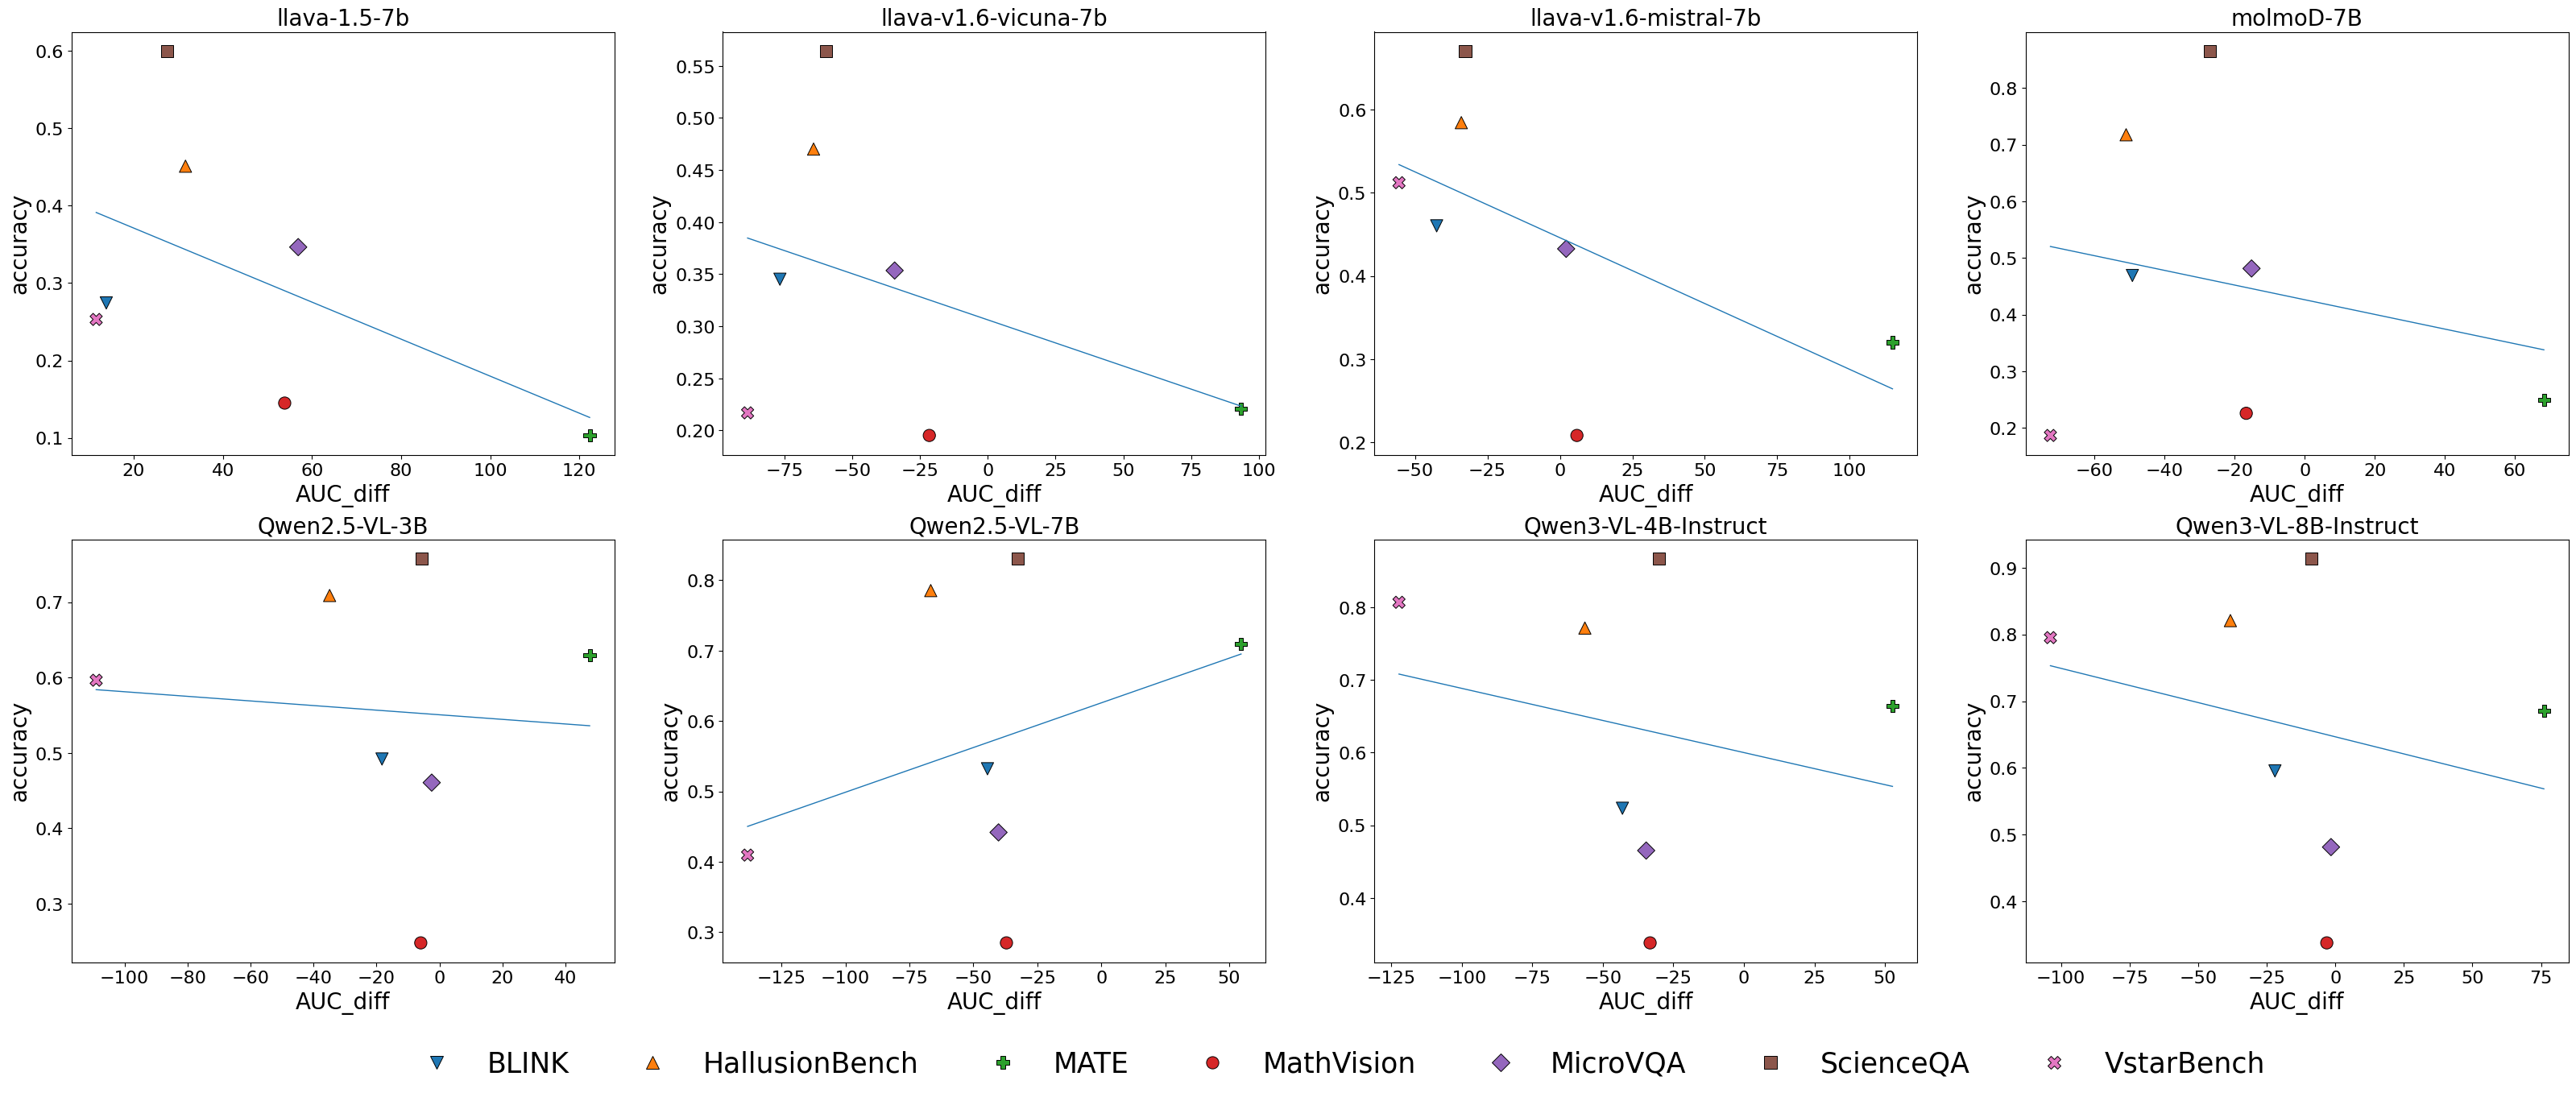

In [7]:
models = dfs["Model"].unique()
colors = {m: cm.tab20(i % 20) for i, m in enumerate(models)}
dfs_ = dfs[dfs['ds_name']!='MATE']
dfs_ = dfs

# Markers per dataset
markers = {
    "MathVision": "o",        # circle
    "ScienceQA": "s",         # square
    "HallusionBench": "^",    # triangle up
    "MicroVQA": "D",              # diamond
    "BLINK": "v",           # triangle down
    "MATE": "P",            # plus (filled)
    "VstarBench":"X"
}

fig, axes = plt.subplots(2, 4, figsize=(40, 15))
axes = axes.flatten()

for ax_idx, model in enumerate(model_ls):
    ax = axes[ax_idx]

    sub = dfs_[dfs_["Model"] == model].sort_values("ds_name")
    sub['marker'] = [markers[i] for i in sub['ds_name']]

    b = sns.scatterplot(
        data=sub,
            x="AUC_diff",
            y="accuracy",
            ax=ax,
            hue="ds_name",
            style="ds_name",
            markers=markers, 
            s=120,
            edgecolor="black",
            linewidth=0.7,
            legend="brief" if ax_idx==len(model_ls)-1 else False
    )
    sns.regplot(data=sub, x="AUC_diff", y="accuracy", ci=None,
        scatter=False, ax=b, line_kws={"lw":1})

    ax.set_title(model, fontsize=20)
    # ax.grid(True, alpha=0.3)
    # b.set_xticklabels([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100], fontsize=16)
    b.set_xticklabels(b.get_xticklabels(), fontsize=16)
    b.set_yticklabels(b.get_yticklabels(), fontsize=16)
    b.set_xlabel(b.get_xlabel(), fontsize=20)
    b.set_ylabel(b.get_ylabel(), fontsize=20)
    

handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(),frameon=False, ncol=7, fontsize=25, loc=(-3,-0.3))
plt.tight_layout()
plt.show()



/tmp/ipykernel_1059695/58994374.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(b.get_xticklabels(), fontsize=16)
/tmp/ipykernel_1059695/58994374.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(b.get_yticklabels(), fontsize=16)
/tmp/ipykernel_1059695/58994374.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(b.get_xticklabels(), fontsize=16)
/tmp/ipykernel_1059695/58994374.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(b.get_yticklabels(), fontsize=16)
/tmp/ipykernel_1059695/58994374.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of tick

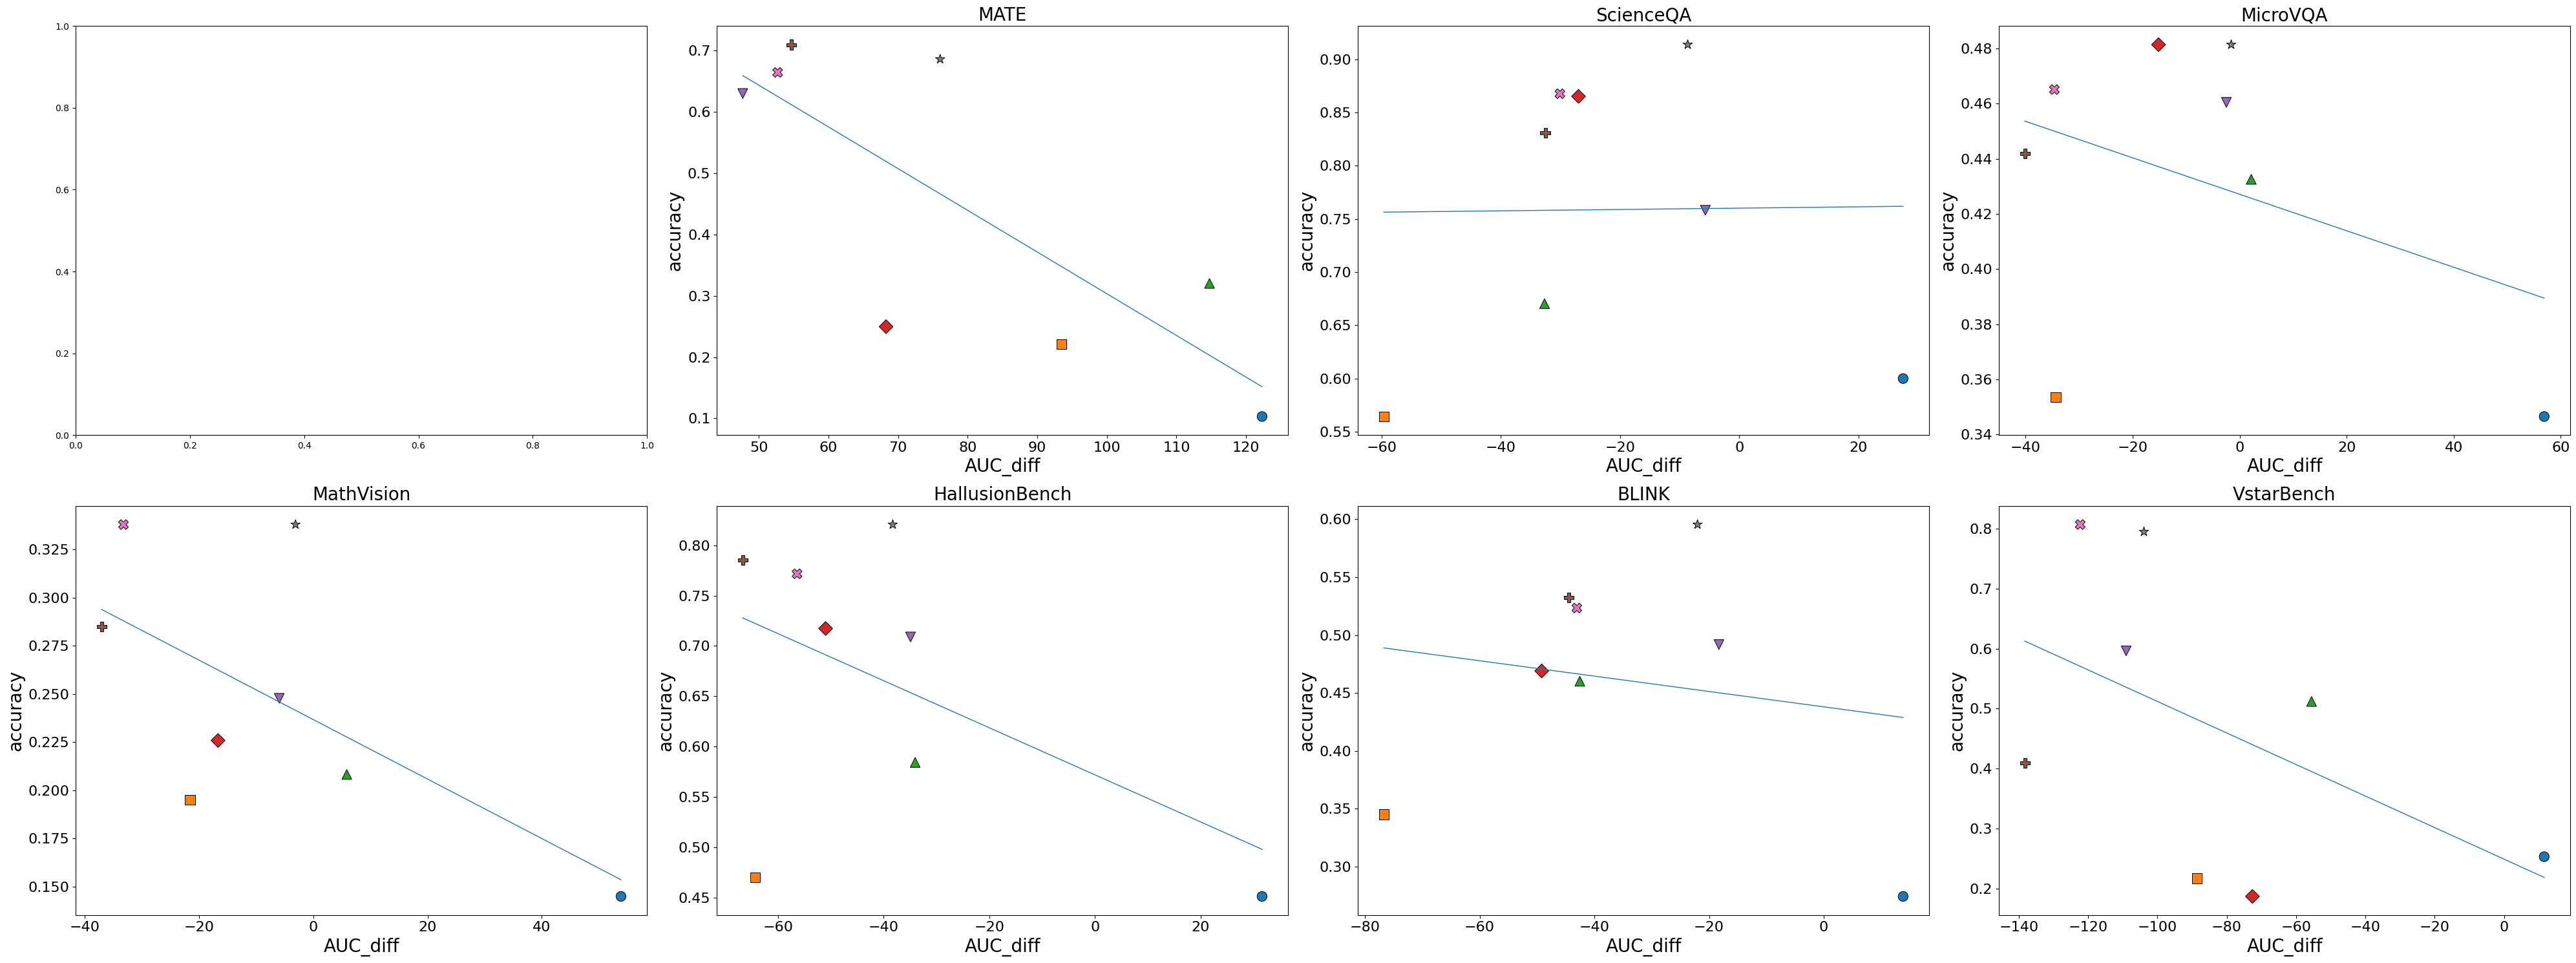

In [8]:
ds_ls = dfs["ds_name"].unique()
colors = {m: cm.tab20(i % 20) for i, m in enumerate(ds_ls)}
# dfs_ = dfs[dfs['ds_name']!='MATE']
dfs_ = dfs

# Markers per dataset
markers = {
    'llava-1.5-7b': "o",
    'llava-v1.6-vicuna-7b': "s",
    'llava-v1.6-mistral-7b': "^",  
    'molmoD-7B': "D",
    'Qwen2.5-VL-3B': "v", 
    'Qwen2.5-VL-7B': "P",
    'Qwen3-VL-4B-Instruct': "X",
    'Qwen3-VL-8B-Instruct': "*"
}


fig, axes = plt.subplots(2, 4, figsize=(40, 15))
axes = axes.flatten()

for ax_idx, ds in enumerate(ds_ls):
    ax = axes[ax_idx+1]

    sub = dfs_[dfs_["ds_name"] == ds].sort_values("ds_name")
    sub['marker'] = [markers[i] for i in sub['Model']]

    b = sns.scatterplot(
        data=sub,
            x="AUC_diff",
            y="accuracy",
            ax=ax,
            hue="Model",
            style="Model",
            markers=markers, 
            s=120,
            edgecolor="black",
            linewidth=0.7,
            legend="brief" if ax_idx==len(model_ls)-1 else False
    )
    sns.regplot(data=sub, x="AUC_diff", y="accuracy", ci=None,
        scatter=False, ax=b, line_kws={"lw":1})

    ax.set_title(ds, fontsize=20)
    # ax.grid(True, alpha=0.3)
    # b.set_xticklabels([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100], fontsize=16)
    b.set_xticklabels(b.get_xticklabels(), fontsize=16)
    b.set_yticklabels(b.get_yticklabels(), fontsize=16)
    b.set_xlabel(b.get_xlabel(), fontsize=20)
    b.set_ylabel(b.get_ylabel(), fontsize=20)


handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(),frameon=False, ncol=8, fontsize=25, )
plt.tight_layout()
plt.show()

